In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("../data/churn.csv")

# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Check target variables
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn"].value_counts(normalize=True) * 100  # this shows hoe many customers stayed and how many left

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [9]:
# Check invalid values
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [10]:
# Convert totalcharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [11]:
# Check missing values
df["TotalCharges"].isnull().sum()

np.int64(11)

In [12]:
# Remove missing values
df.dropna(inplace=True)

In [13]:
# Verify dataset shape again
print(df.shape)

(7032, 21)


In [14]:
df.drop("customerID", axis=1, inplace=True)

In [15]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [16]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [17]:
print(df.shape)
print(df_encoded.shape)

(7032, 20)
(7032, 31)


In [18]:
# First Visualization
plt.style.use("default")

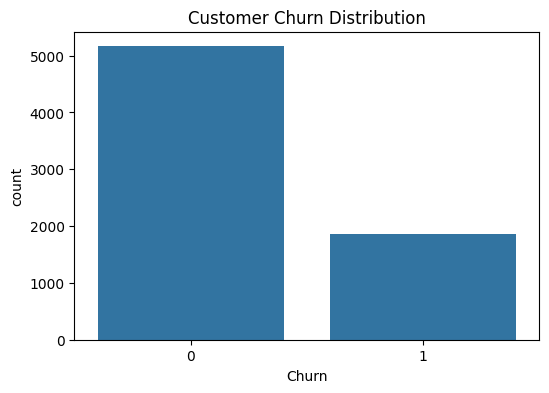

In [19]:
# Visualization 1 : Churn Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

### Around 26.5% of customers churned while 73.5% remained, indicating a class imbalance problem.

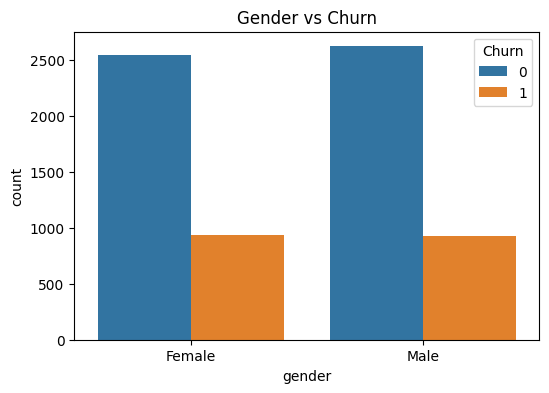

In [20]:
# Visualization 2 : Gender VS Churn
plt.figure(figsize=(6,4))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

plt.title("Gender vs Churn")
plt.show()

### Check whether males or females churn more frequently. 

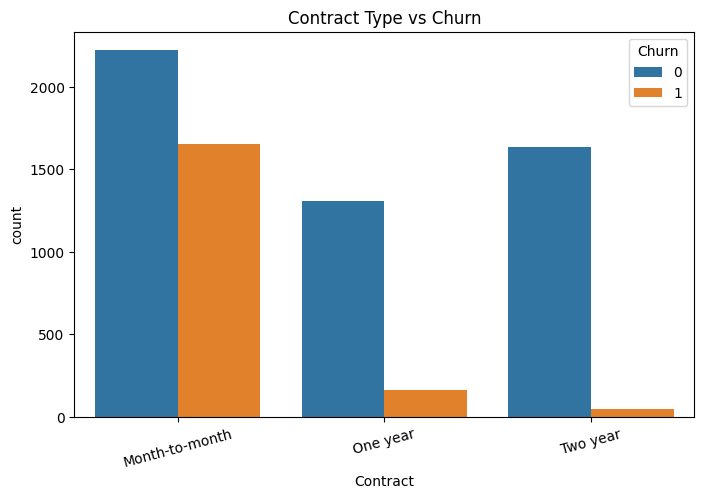

In [21]:
# Visualization 3 : Contract Type VS Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

### Observation: 
Month-to-month customers churn much more frequently.
One-year and Two-year contracts have very low churn.

### Business Insight:
Customers with long-term contracts are more loyal and less likely to leave.

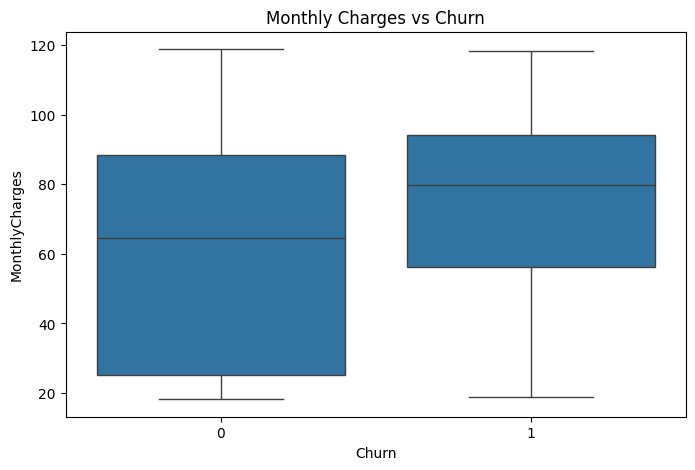

In [22]:
# Visualization 4 : Monthly Charges VS Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

### Observation:
Churned customers generally have higher monthly charges.

### Business Insight:
Higher monthly fees may increase the likelihood of customer churn.

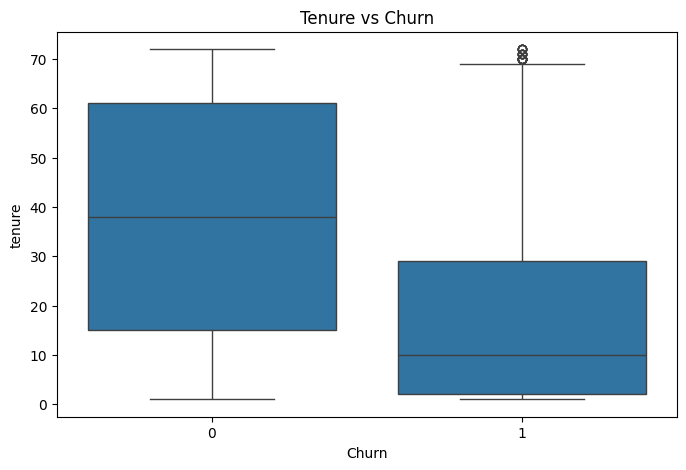

In [23]:
# Visualization 5 : Tenure VS Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

### Observation:
Customers who churn have much lower tenure.
Customers who stay have much higher tenure.

### Business Insight:
New customers are at the highest risk of churning. Customer retention efforts should focus on the first few months after onboarding.

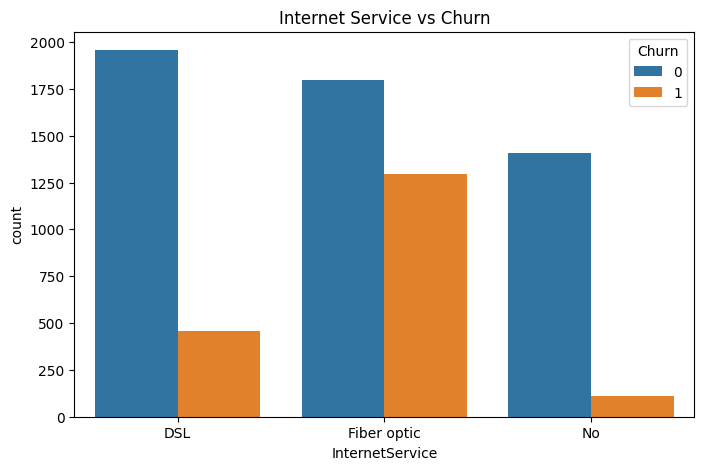

In [24]:
# Visualization 6 : Internet Service VS Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Churn")
plt.show()

### Observation:
Fiber optic customers churn the most.
DSL customers churn less.
Customers without internet service have the lowest churn.

### Business Insight:
Fiber optic customers may be experiencing pricing or service quality issues that increase churn.

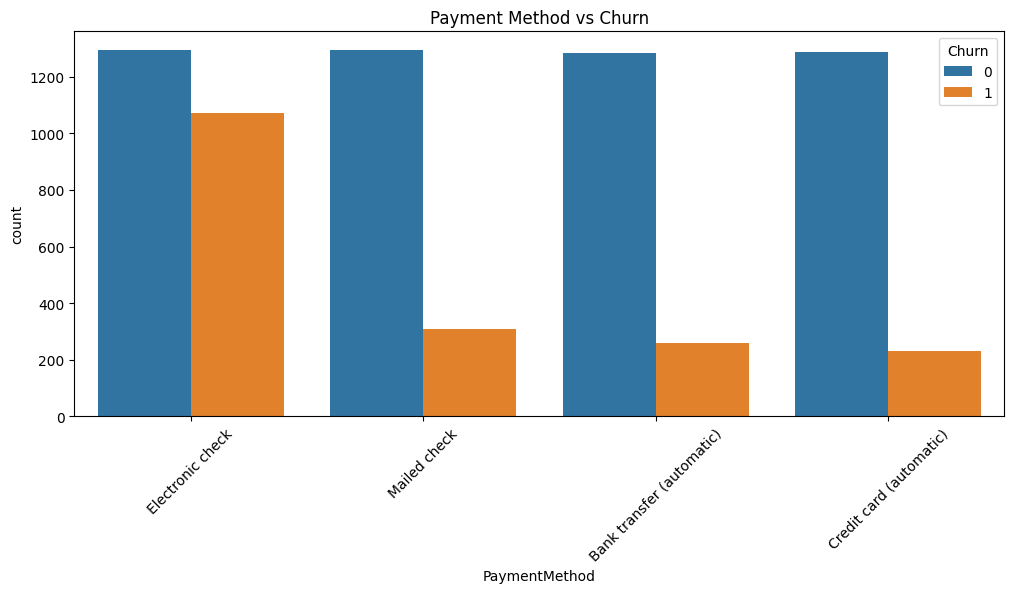

In [25]:
# Visualization 7 : Payment Method VS Churn
plt.figure(figsize=(12,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

### Observation :
Electronic check customers have the highest churn.
Automatic payment methods have much lower churn.

### Business Insight:
Customers enrolled in automatic payments are more loyal and less likely to leave.

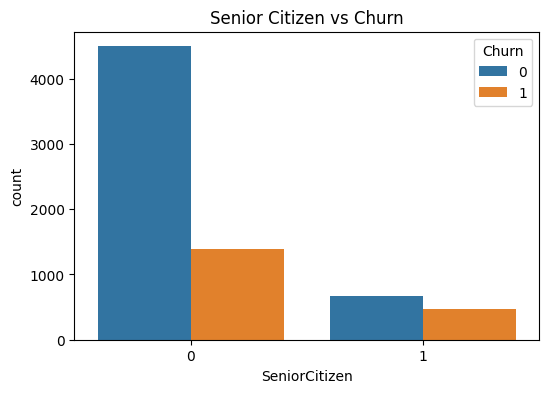

In [26]:
# Visualization 8 : Senior Citizen VS Churn
plt.figure(figsize=(6,4))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Senior Citizen vs Churn")
plt.show()

### Observation :
Senior citizens churn proportionally more than non-senior customers.

### Business Insight:
Senior citizens may require targeted support and retention strategies.

## Key Insights

1. Customers on month-to-month contracts exhibit significantly higher churn rates.

2. Customers with higher monthly charges are more likely to churn.

3. Customers with shorter tenure tend to leave more frequently.

4. Gender has minimal impact on churn behavior.

5. Long-term contracts are associated with better customer retention.

# Machine Learning Phase

In [27]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [28]:
# Encode target variable : encode churn
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [29]:
# Check
df["Churn"].value_counts()

Series([], Name: count, dtype: int64)

In [30]:
# One Hot Encoding
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [31]:
# Check shape
print(df_encoded.shape)

(7032, 31)


In [32]:
# Split features and target
X = df_encoded.drop("Churn", axis=1)

y = df_encoded["Churn"]

In [33]:
print(df["Churn"].unique())

[nan]


In [34]:
print(df["Churn"].isnull().sum())

7032


In [35]:
df = pd.read_csv("../data/churn.csv")

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

df.drop("customerID", axis=1, inplace=True)

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [36]:
print(df["Churn"].unique())
print(df["Churn"].isnull().sum())

[0 1]
0


In [37]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [38]:
print(y.isnull().sum())

0


In [39]:
# Train-Test split
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [40]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [41]:
# Evaluate Logistic regression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(
    y_test,
    y_pred_lr
))

Accuracy: 0.7256574271499645
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



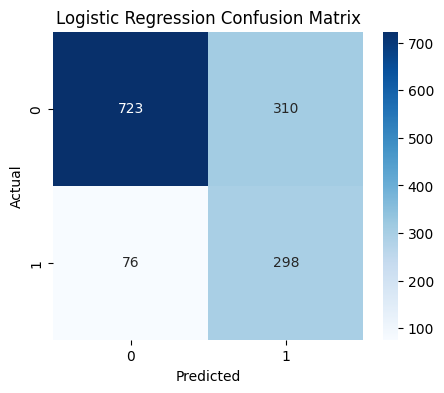

In [42]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Interpretation
80% of customers who will churn.
Missing a churning customer is more costly than incorrectly flagging a loyal customer.


In [43]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [44]:
# Evaluate Random Forest
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Accuracy: 0.7683013503909026
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.55      0.65      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.77      1407



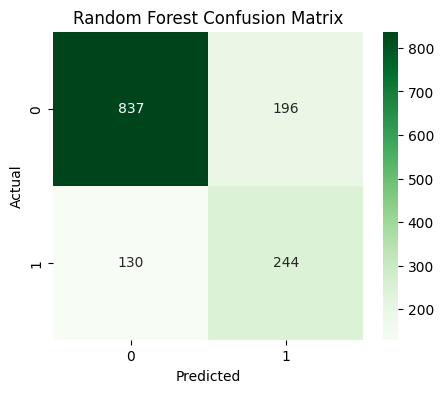

In [45]:
# Random Forest Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,TotalCharges,0.175906
1,tenure,0.164585
2,MonthlyCharges,0.152576
25,Contract_Two year,0.061387
10,InternetService_Fiber optic,0.039283
28,PaymentMethod_Electronic check,0.037501
24,Contract_One year,0.031527
13,OnlineSecurity_Yes,0.028469
4,gender_Male,0.026113
19,TechSupport_Yes,0.023117


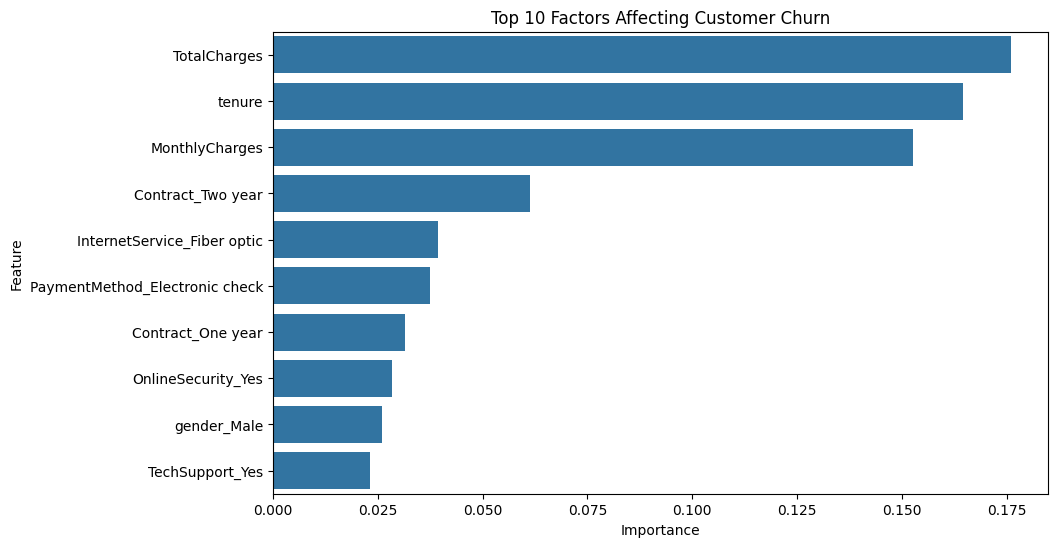

In [47]:
# Visualize Top 10 Features
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title(
    "Top 10 Factors Affecting Customer Churn"
)

plt.show()

#### Contract type, tenure, monthly charges, and internet service were identified as the most influential factors affecting customer churn.

### Which model should you use?

Random Forest is the better overall model because:

Higher Accuracy
Higher Precision
Better overall balance

### To mention:

Multiple classification algorithms were evaluated, and Random Forest was selected due to its superior overall performance and ability to identify key churn drivers through feature importance analysis.

## Business Insights
- Customers with higher total and monthly charges are more likely to churn.
- Long-tenure customers are less likely to leave.
- Two-year contracts significantly improve retention.
- Fiber optic customers show higher churn rates.
- Electronic check users churn more frequently than customers using automatic payment methods.

In [48]:
### Save the Model
import joblib

joblib.dump(
    rf,
    "../models/churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [49]:
import os

os.listdir("../models")

['churn_model.pkl']